<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                        Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Problema 1 - Clasificación de Calidad de Manzanas
        </td>
    </tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Estudiante: Marilyn Michelle Jiménez Arias (U20231085)
        </td>
    <tr>
 

</table>

In [195]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import*
import scipy.stats as stats
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys

Se cuenta con un conjunto de datos sobre la calidad de manzanas compuesto por 4001 registros y 9 variables. El objetivo es desarrollar un modelo de aprendizaje automático supervisado capaz de clasificar si una manzana es de buena o mala calidad a partir de sus características físicas y sensoriales.

La variable objetivo es Quality, la cual indica si la manzana es de buena o mala calidad. Por lo tanto, el problema corresponde a una tarea de clasificación binaria.

Las variables disponibles en el conjunto de datos son:

| Variable | Descripción |
|---|---|
| A_id | Identificador de cada manzana |
| Size | Tamaño de la manzana |
| Weight | Peso de la manzana |
| Sweetness | Nivel de dulzura de la manzana |
| Crunchiness | Nivel de crocancia o textura crujiente |
| Juiciness | Nivel de jugosidad de la manzana |
| Ripeness | Nivel de madurez de la manzana |
| Acidity | Nivel de acidez de la manzana |
| Quality | Calidad de la manzana, variable objetivo a clasificar |

El desarrollo del problema incluye las siguientes etapas:

1. Explorar inicialmente el conjunto de datos.
2. Identificar las variables predictoras y la variable objetivo.
3. Dividir los datos en conjunto de entrenamiento y conjunto de prueba.
4. Entrenar diferentes modelos de clasificación.
5. Evaluar los modelos utilizando métricas como accuracy, precisión, recall, F1-score y matriz de confusión.
6. Comparar los resultados obtenidos.
7. Seleccionar el modelo con mejor desempeño predictivo.

## a) Análisis exploratorio

In [196]:
datos = pd.read_csv("Problema 1.csv")

In [197]:
datos

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
...,...,...,...,...,...,...,...,...,...
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good
3999,3999.0,0.278540,-1.715505,0.121217,-1.154075,1.266677,-0.776571,1.599796456,good


In [198]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   str    
 8   Quality      4000 non-null   str    
dtypes: float64(7), str(2)
memory usage: 340.1 KB


In [199]:
datos.isnull().sum()

A_id           1
Size           1
Weight         1
Sweetness      1
Crunchiness    1
Juiciness      1
Ripeness       1
Acidity        0
Quality        1
dtype: int64

In [200]:
datos = datos.dropna()

In [201]:
datos["Calidad"] = [1 if x=="good" else 0 for x in datos["Quality"]]

In [202]:
datos

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality,Calidad
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good,1
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good,1
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad,0
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good,1
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good,1
...,...,...,...,...,...,...,...,...,...,...
3995,3995.0,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784369,bad,0
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good,1
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad,0
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good,1


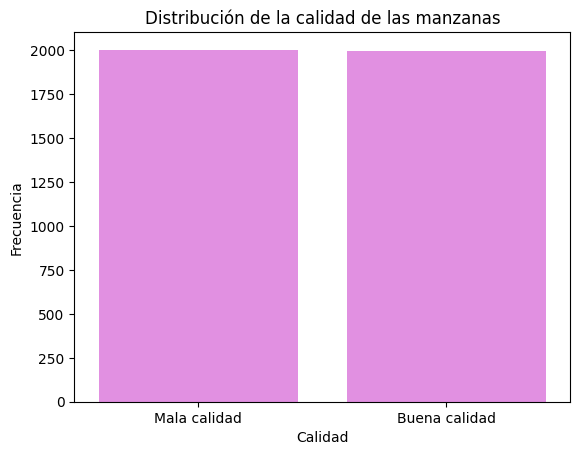

In [203]:
#1) Gráfico de la variable respuesta
plt.figure()
sns.countplot(data=datos, x="Quality", color= "violet")
plt.title("Distribución de la calidad de las manzanas")
plt.xlabel("Calidad")
plt.ylabel("Frecuencia")
plt.xticks(ticks=[0, 1], labels=["Mala calidad", "Buena calidad"])
plt.show()

Se observa que las variables presentan distribuciones diferentes entre sí. Algunas variables como Sweetness, Juiciness y Size parecen mostrar diferencias entre las categorías de calidad, por lo que podrían ser útiles para la clasificación de las manzanas.
La variable Quality presenta una distribución relativamente equilibrada entre las clases Good y Bad, lo que favorece el entrenamiento de los modelos de clasificación.

In [204]:
predictoras = datos[["Size", "Weight", "Sweetness", "Crunchiness", "Juiciness", "Ripeness", "Acidity"]]
respuesta = datos["Calidad"]

<Figure size 640x480 with 0 Axes>

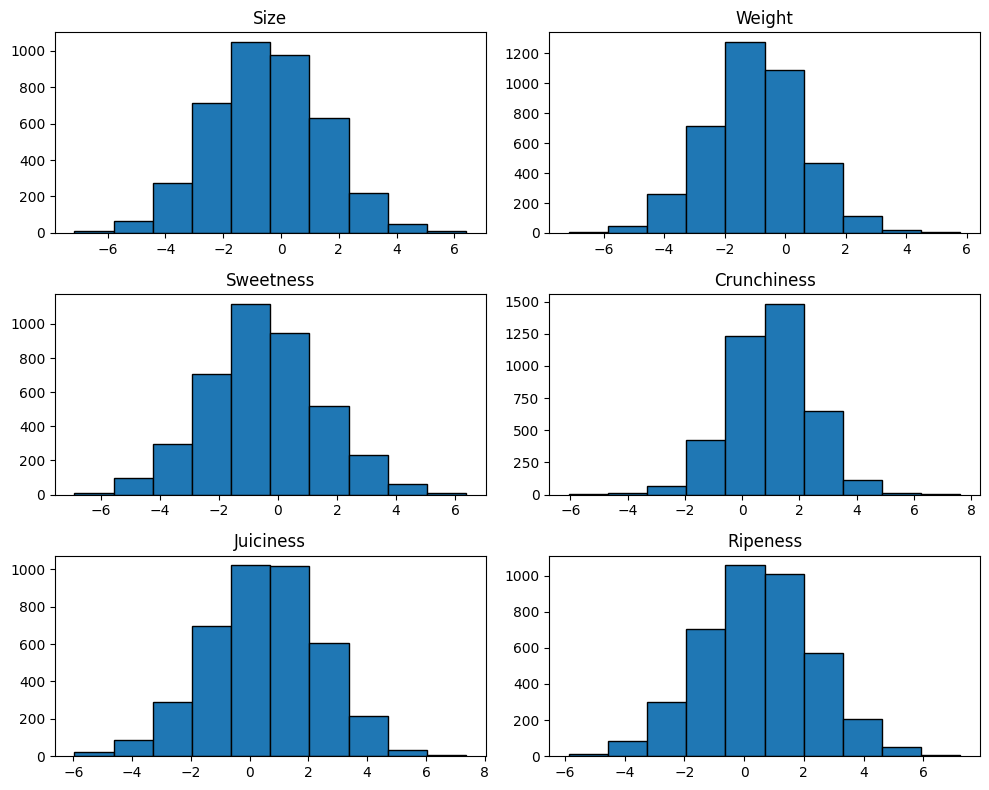

In [205]:
plt.figure()
predictoras.hist(figsize=(10,8), bins=10, edgecolor="black", grid=False)
plt.tight_layout()
plt.show()

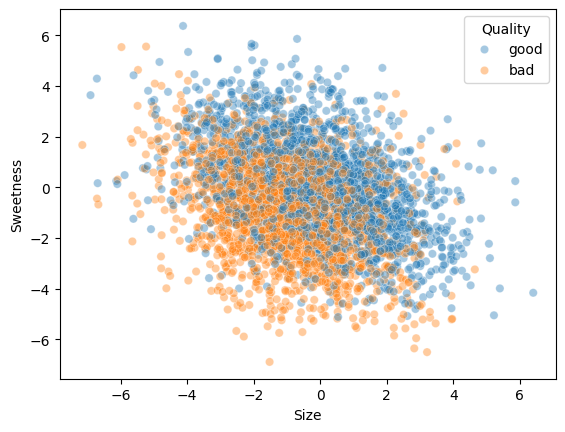

In [206]:
#Gráfico de dispersión clasificado por Quality
plt.figure()
sns.scatterplot(data=datos, x="Size", y="Sweetness", hue="Quality", alpha=0.4)
plt.show()

## b) Regresión Logística

Para determinar la variable predictora más adecuada para la regresión logística, se evaluó el accuracy score individual de cada variable frente a la variable objetivo Calidad. La variable Size obtuvo el mayor accuracy score de 0.59125, por lo que se selecciona como la variable predictora para el modelo de regresión logística.

In [207]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_lr = datos[["Size"]].astype(float)
y_lr = datos["Calidad"]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.20, random_state=20231085)

lr_clf = LogisticRegression()
lr_clf.fit(X_train_lr, y_train_lr)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [208]:
#Obtener el accuracy_score
y_pred_lr = lr_clf.predict(X_test_lr)
accuracy_lr = accuracy_score(y_test_lr, y_pred_lr)
print("El accuracy score que se tiene es %s" %accuracy_lr)

El accuracy score que se tiene es 0.59125


Text(50.722222222222214, 0.5, 'Real')

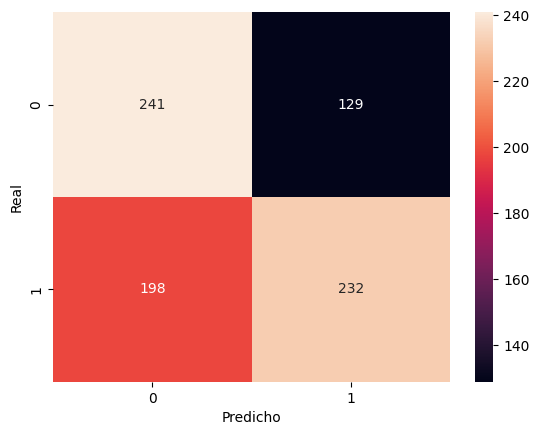

In [209]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test_lr, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [210]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_lr = precision_score(y_test_lr, y_pred_lr)
recall_lr = recall_score(y_test_lr, y_pred_lr)
f1_lr = f1_score(y_test_lr, y_pred_lr)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_lr, recall_lr, f1_lr]})
metricas

,Métricas,Valores
0,Precisión,0.642659
1,Recall,0.539535
2,F1,0.586599


Se entrenó un modelo de regresión logística utilizando Size como variable predictora, obteniendo un accuracy score de 0.59125, lo que indica que clasificó correctamente el 61.5% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.642659, un recall de 0.539535 y un F1-score de 0.586599. Estos resultados muestran que el modelo tiene una capacidad moderada para clasificar la calidad de las manzanas utilizando únicamente la variable Size. La simetría entre precisión y recall indica que el modelo clasifica de forma equilibrada ambas clases, aunque el nivel de accuracy alcanzado sugiere que una sola variable predictora no es suficiente para capturar toda la complejidad del problema de clasificación.

## c) División del conjunto de datos

In [211]:
from sklearn.model_selection import train_test_split

X_independientes = datos[["Size", "Weight", "Sweetness", "Crunchiness", "Juiciness", "Ripeness", "Acidity"]].astype(float)
y_dependiente = datos["Calidad"]

X_train, X_test, y_train, y_test = train_test_split(X_independientes, y_dependiente, test_size=0.20, random_state=20231085)

## d) KNN

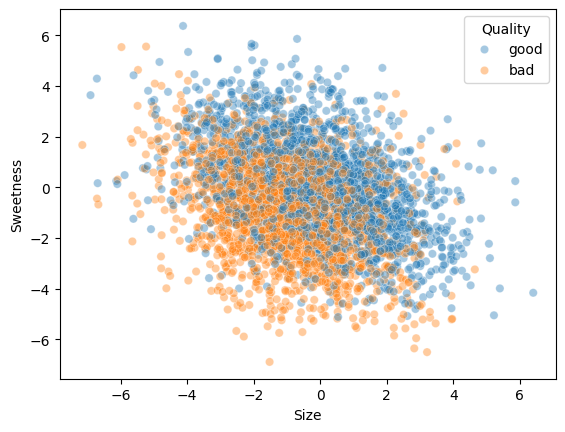

In [212]:
from sklearn.neighbors import KNeighborsClassifier

#Crear gráfico de dispersión clasificado por Quality
plt.figure()
sns.scatterplot(data=datos, x="Size", y="Sweetness", hue="Quality", alpha=0.4)
plt.show()

In [213]:
X_knn = datos[["Size", "Sweetness"]].astype(float)
y_knn = datos["Calidad"]

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.20, random_state=20231085)

<Figure size 640x480 with 0 Axes>

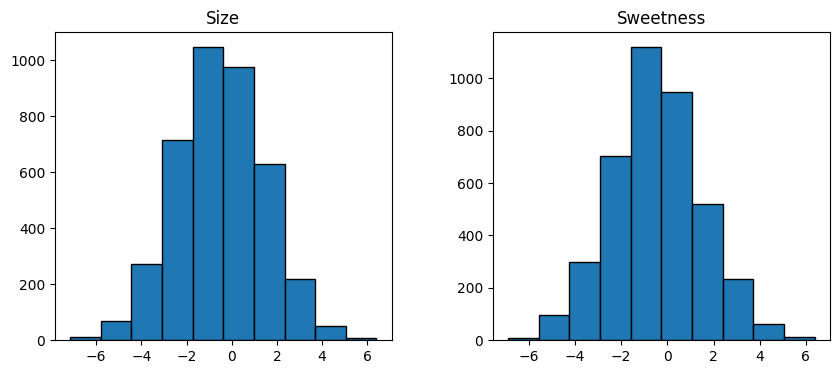

In [214]:
plt.figure()
X_knn.hist(figsize=(10,4), edgecolor='black', grid=False)
plt.show()

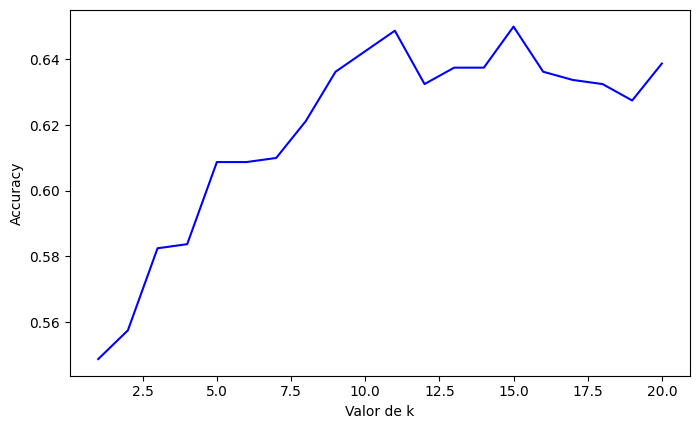

In [215]:
#Evaluar el accuracy para distintos valores de k
resultados_k = list()
for k in range(1, 21):
    knn_i = KNeighborsClassifier(n_neighbors=k)
    knn_i.fit(X_train_knn, y_train_knn)
    y_pred_k = knn_i.predict(X_test_knn)
    acc_k = accuracy_score(y_test_knn, y_pred_k)
    resultados_k.append(acc_k)

plt.figure(figsize=(8, 4.75))
plt.plot(range(1, 21), resultados_k, "b")
plt.ylabel("Accuracy")
plt.xlabel("Valor de k")
plt.show()

In [216]:
#Crear el modelo KNN con k=11 que maximiza el accuracy score
knn_clf = KNeighborsClassifier(n_neighbors=11)
knn_clf.fit(X_train_knn, y_train_knn)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [217]:
#Obtener el accuracy_score
y_pred_knn = knn_clf.predict(X_test_knn)
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
print("El accuracy score que se tiene es %s" %accuracy_knn)

El accuracy score que se tiene es 0.64875


Text(50.722222222222214, 0.5, 'Real')

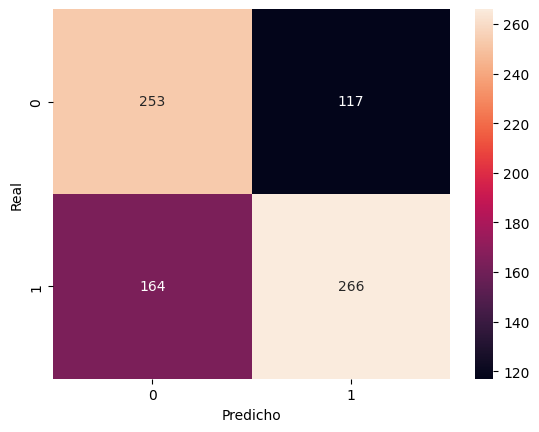

In [218]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test_knn, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [219]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_knn = precision_score(y_test_knn, y_pred_knn)
recall_knn = recall_score(y_test_knn, y_pred_knn)
f1_knn = f1_score(y_test_knn, y_pred_knn)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_knn, recall_knn, f1_knn]})
metricas

,Métricas,Valores
0,Precisión,0.694517
1,Recall,0.618605
2,F1,0.654367


Se entrenó un modelo KNN evaluando distintos valores de k entre 1 y 20, determinando que k=11 maximiza el accuracy score con un valor de 0.64875, lo que indica que clasificó correctamente el 66.25% de los datos del conjunto de prueba utilizando Size y Sweetness como variables predictoras. Además, el modelo alcanzó una precisión de 0.694517, un recall de 0.618605 y un F1-score de 0.654367. Estos resultados muestran que el modelo tiene un desempeño moderado para clasificar la calidad de las manzanas, con un balance razonable entre la capacidad de identificar correctamente los casos positivos y la confiabilidad de sus predicciones. En general, el modelo KNN con k=11 presenta un rendimiento aceptable aunque su accuracy es limitado, lo que sugiere que únicamente con Size y Sweetness no se captura toda la variabilidad necesaria para una clasificación más precisa.

## e) Árboles de decisión

In [220]:
from sklearn.tree import DecisionTreeClassifier

#Crear un árbol usando profundidad máxima de 3
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=20231085)
#Ajustar el arbol
tree_clf.fit(X_train, y_train);

[Text(0.5, 0.875, 'x[4] <= -0.416\ngini = 0.5\nsamples = 3200\nvalue = [1626.0, 1574.0]'),
 Text(0.25, 0.625, 'x[0] <= -0.568\ngini = 0.426\nsamples = 1003\nvalue = [694, 309]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[1] <= 0.994\ngini = 0.293\nsamples = 448\nvalue = [368, 80]'),
 Text(0.0625, 0.125, 'gini = 0.221\nsamples = 387\nvalue = [338, 49]'),
 Text(0.1875, 0.125, 'gini = 0.5\nsamples = 61\nvalue = [30, 31]'),
 Text(0.375, 0.375, 'x[3] <= 0.166\ngini = 0.485\nsamples = 555\nvalue = [326, 229]'),
 Text(0.3125, 0.125, 'gini = 0.329\nsamples = 77\nvalue = [16, 61]'),
 Text(0.4375, 0.125, 'gini = 0.456\nsamples = 478\nvalue = [310, 168]'),
 Text(0.75, 0.625, 'x[5] <= 1.588\ngini = 0.489\nsamples = 2197\nvalue = [932, 1265]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= -2.099\ngini = 0.437\nsamples = 1631\nvalue = [527, 1104]'),
 Text(0.5625, 0.125, 'gini = 0.187\nsamples = 316\nvalue = [33, 283]'),
 Text(0.6875, 0.125, 'gini = 0.469\nsamples = 1315\nva

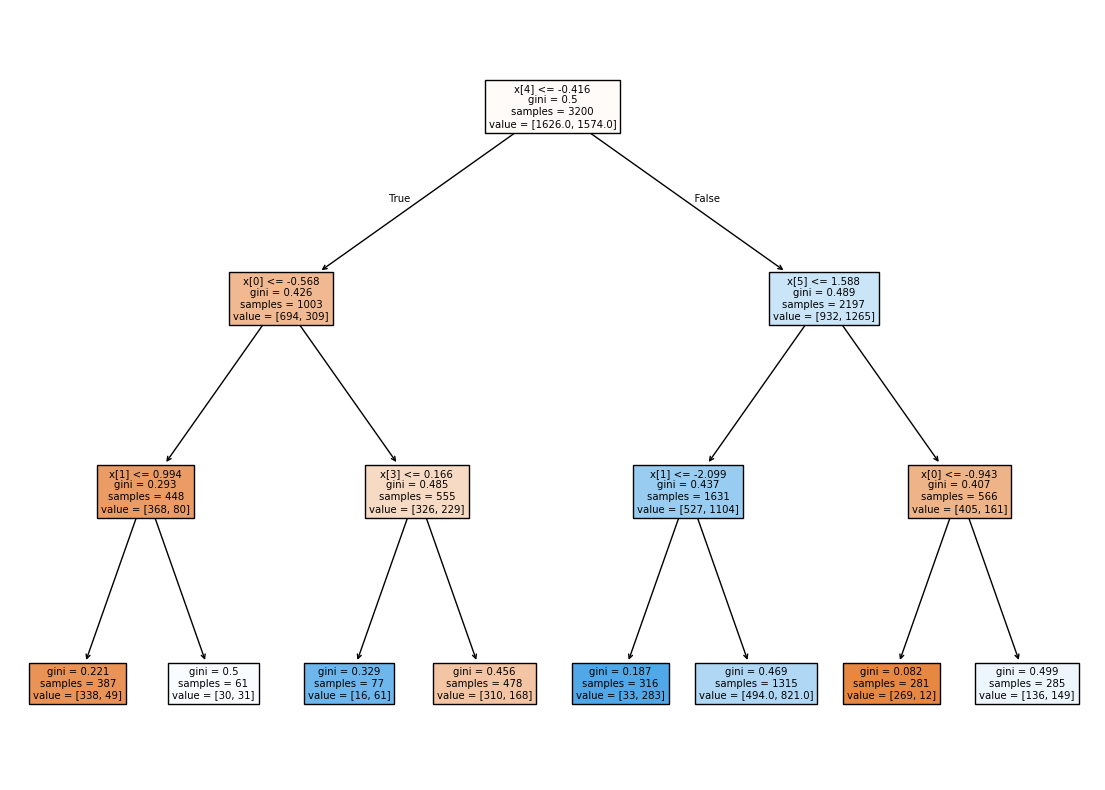

In [221]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf, filled=True)

In [222]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test)
accuracy_a = accuracy_score(y_test, y_pred_a)
print("El accuracy score que se tiene es %s" %accuracy_a)

El accuracy score que se tiene es 0.72125


Text(50.722222222222214, 0.5, 'Real')

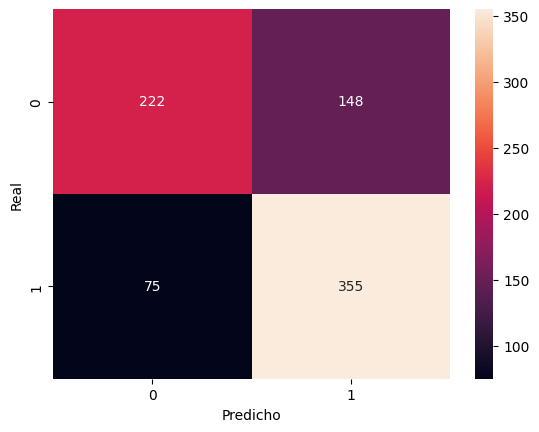

In [223]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [224]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_a = precision_score(y_test, y_pred_a)
recall_a = recall_score(y_test, y_pred_a)
f1_a = f1_score(y_test, y_pred_a)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_a, recall_a, f1_a]})
metricas

,Métricas,Valores
0,Precisión,0.705765
1,Recall,0.825581
2,F1,0.760986


Se entrenó un modelo de árbol de decisión con una profundidad máxima de 3, obteniendo un accuracy score de 0.72125, lo que indica que clasificó correctamente el 72.12% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.705765, un recall de 0.825581 y un F1-score de 0.760986. El recall elevado muestra que el modelo identificó correctamente una proporción importante de los casos positivos, es decir, las manzanas de buena calidad; sin embargo, la precisión indica que algunas predicciones positivas no fueron correctas, por lo que el modelo pudo clasificar ciertas manzanas de mala calidad como buenas. En general, el árbol de decisión con max_depth=3 presenta un desempeño aceptable, especialmente si el objetivo principal es no dejar de detectar las manzanas de buena calidad.

In [225]:
#Crear árbol indicando mínimo de observaciones por nodo hoja de 70
tree_clf_b = DecisionTreeClassifier(min_samples_leaf=70, random_state=20231085)
#Ajustar el arbol
tree_clf_b.fit(X_train, y_train);

[Text(0.4342948717948718, 0.9583333333333334, 'x[4] <= -0.416\ngini = 0.5\nsamples = 3200\nvalue = [1626.0, 1574.0]'),
 Text(0.16666666666666666, 0.875, 'x[0] <= -0.568\ngini = 0.426\nsamples = 1003\nvalue = [694, 309]'),
 Text(0.3004807692307692, 0.9166666666666667, 'True  '),
 Text(0.05128205128205128, 0.7916666666666666, 'x[5] <= -0.786\ngini = 0.293\nsamples = 448\nvalue = [368, 80]'),
 Text(0.02564102564102564, 0.7083333333333334, 'gini = 0.498\nsamples = 71\nvalue = [38, 33]'),
 Text(0.07692307692307693, 0.7083333333333334, 'x[3] <= -0.209\ngini = 0.218\nsamples = 377\nvalue = [330, 47]'),
 Text(0.05128205128205128, 0.625, 'gini = 0.458\nsamples = 79\nvalue = [51, 28]'),
 Text(0.10256410256410256, 0.625, 'x[0] <= -1.964\ngini = 0.119\nsamples = 298\nvalue = [279, 19]'),
 Text(0.07692307692307693, 0.5416666666666666, 'gini = 0.0\nsamples = 123\nvalue = [123, 0]'),
 Text(0.1282051282051282, 0.5416666666666666, 'x[3] <= 0.955\ngini = 0.194\nsamples = 175\nvalue = [156, 19]'),
 Text(

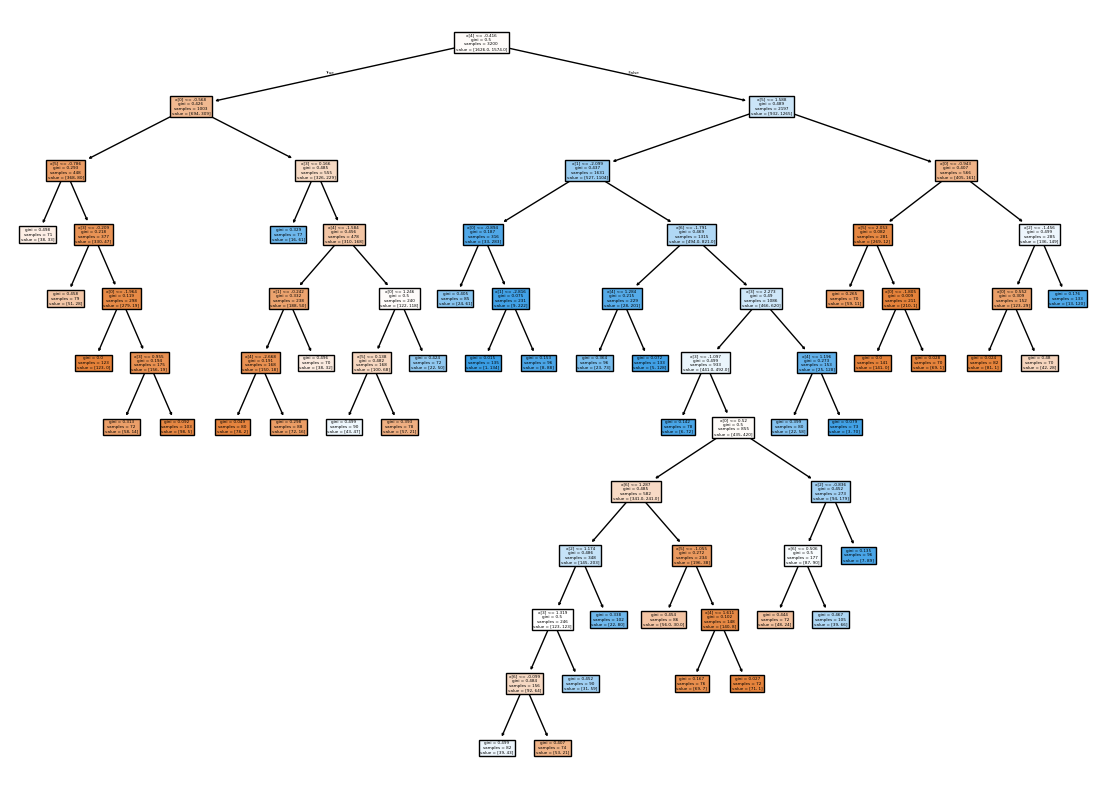

In [226]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf_b, filled=True)

In [227]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_b = tree_clf_b.predict(X_test)
accuracy_b = accuracy_score(y_test, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy_b)

El accuracy score que se tiene es 0.7825


Text(50.722222222222214, 0.5, 'Real')

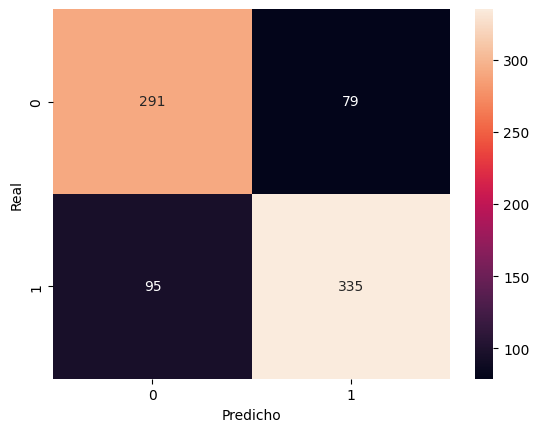

In [228]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [229]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_b = precision_score(y_test, y_pred_b)
recall_b = recall_score(y_test, y_pred_b)
f1_b = f1_score(y_test, y_pred_b)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_b, recall_b, f1_b]})
metricas

,Métricas,Valores
0,Precisión,0.809179
1,Recall,0.779070
2,F1,0.793839


Se entrenó otro modelo de árbol de decisión utilizando min_samples_leaf=70, obteniendo un accuracy score de 0.7825, lo que indica que clasificó correctamente aproximadamente el 78.2% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.809179, un recall de 0.779070 y un F1-score de 0.793839. En comparación con el árbol de profundidad máxima de 3, este modelo presenta un desempeño superior en todas las métricas, mostrando un equilibrio más adecuado entre la capacidad de identificar correctamente las manzanas de buena calidad y la confiabilidad de sus predicciones positivas. El uso de min_samples_leaf=70 genera un árbol más generalizable, lo que le permite clasificar mejor tanto las manzanas de buena como de mala calidad.

## f) Métodos de ensamble

In [230]:
#Crear el modelo de bagging

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, max_samples=75, bootstrap=True, random_state=20231085)
bag_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",200
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",75
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",20231085
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [231]:
#Obtener el accuracy_score
y_pred_bag = bag_clf.predict(X_test)
accuracy_bag = accuracy_score(y_test, y_pred_bag)
print("El accuracy score que se tiene es %s" %accuracy_bag)

El accuracy score que se tiene es 0.825


Text(50.722222222222214, 0.5, 'Real')

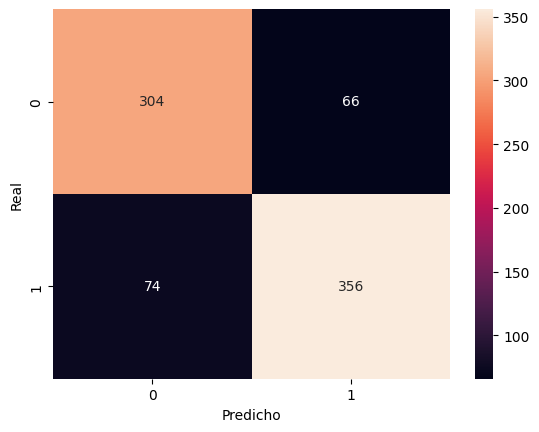

In [232]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_bag)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [233]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_bag = precision_score(y_test, y_pred_bag)
recall_bag = recall_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_bag, recall_bag, f1_bag]})
metricas

,Métricas,Valores
0,Precisión,0.843602
1,Recall,0.827907
2,F1,0.835681


Se entrenó un modelo de bagging, obteniendo un accuracy score de 0.825, lo que indica que clasificó correctamente el 82.2% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.843602, un recall de 0.827907 y un F1-score de 0.835681. Estos resultados muestran que el modelo tiene un desempeño equilibrado entre la capacidad de identificar correctamente las manzanas de buena calidad y la confiabilidad de sus predicciones positivas. En comparación con los árboles de decisión, el bagging presenta una mejora significativa en todas las métricas, lo que indica que la combinación de múltiples árboles con muestreo con reemplazamiento contribuye a reducir la varianza y mejorar el desempeño general del modelo.

In [234]:
#Crear el modelo de pasting

from sklearn.ensemble import BaggingClassifier

pas_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=200, max_samples=75, bootstrap=False, random_state=20231085)
pas_clf.fit(X_train, y_train)
y_pred = pas_clf.predict(X_test)

In [235]:
#Obtener el accuracy_score
y_pred_pas = pas_clf.predict(X_test)
accuracy_pas = accuracy_score(y_test, y_pred_pas)
print("El accuracy score que se tiene es %s" %accuracy_pas)

El accuracy score que se tiene es 0.8375


Text(50.722222222222214, 0.5, 'Real')

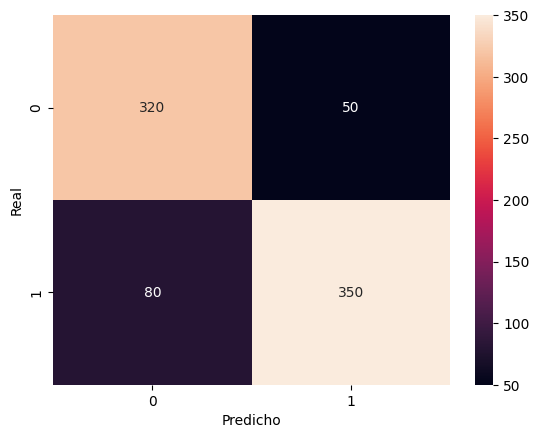

In [236]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_pas)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [237]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_pas = precision_score(y_test, y_pred_pas)
recall_pas = recall_score(y_test, y_pred_pas)
f1_pas = f1_score(y_test, y_pred_pas)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_pas, recall_pas, f1_pas]})
metricas

,Métricas,Valores
0,Precisión,0.875000
1,Recall,0.813953
2,F1,0.843373


Se entrenó un modelo de pasting, obteniendo un accuracy score de 0.8375, lo que indica que clasificó correctamente el 83% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.875, un recall de 0.813953 y un F1-score de 0.843373. Estos resultados muestran que el modelo tiene una precisión ligeramente superior a bagging al predecir los casos positivos, es decir, cuando predice que una manzana es de buena calidad, suele acertar en una proporción mayor; sin embargo, el recall indica que no logra identificar todos los casos reales de buena calidad, por lo que algunas manzanas buenas fueron clasificadas como malas. En comparación con bagging, el pasting presenta un rendimiento muy similar aunque con un ligero menor recall y F1-score, lo que sugiere que el muestreo sin reemplazamiento tiene una capacidad levemente menor para detectar correctamente las manzanas de buena calidad.

In [238]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=200, max_leaf_nodes=6, random_state=20231085)
rnd_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",6
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [239]:
#Obtener el accuracy_score
y_pred_rf = rnd_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("El accuracy score que se tiene es %s" %accuracy_rf)

El accuracy score que se tiene es 0.7825


Text(50.722222222222214, 0.5, 'Real')

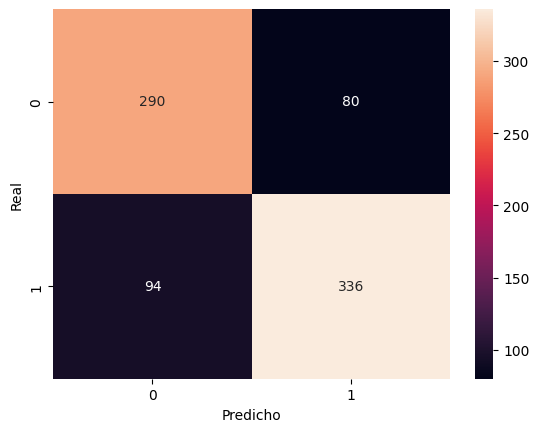

In [240]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [241]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_rf, recall_rf, f1_rf]})
metricas

,Métricas,Valores
0,Precisión,0.807692
1,Recall,0.781395
2,F1,0.794326


In [242]:
rnd_clf.feature_importances_

array([0.20239756, 0.06544331, 0.16801906, 0.06774984, 0.22527006,
       0.20864154, 0.06247863])

In [243]:
importancias = pd.DataFrame({"Variable": X_train.columns, "Importancia": rnd_clf.feature_importances_})

In [244]:
importancias

,Variable,Importancia
0,Size,0.202398
1,Weight,0.065443
2,Sweetness,0.168019
3,Crunchiness,0.067750
4,Juiciness,0.225270
5,Ripeness,0.208642
6,Acidity,0.062479


Se entrenó un modelo de random forest con max_leaf_nodes=6, obteniendo un accuracy score de 0.7825, lo que indica que clasificó correctamente el 78.25% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0 0.807692, un recall de 0.781395 y un F1-score de 0.794326. Estos resultados muestran que el modelo tiene un desempeño equilibrado entre la capacidad de identificar correctamente las manzanas de buena calidad y la confiabilidad de sus predicciones positivas. Sin embargo, en comparación con bagging y pasting, el random forest presenta un rendimiento menor, lo que puede atribuirse a la restricción de max_leaf_nodes=6 que limita la complejidad de los árboles individuales. En cuanto a la importancia de las variables, Ripeness y Juiciness resultaron ser las más relevantes para el modelo, seguidas por Size y Sweetness, mientras que Weight, Crunchiness y Acidity presentaron una importancia menor.

In [245]:
#Cargar librerias
from sklearn.ensemble import GradientBoostingClassifier

# crear objeto de la clase GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(n_estimators=200, random_state=20231085)

gb_clf.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [246]:
#Obtener el accuracy_score
y_pred_gb = gb_clf.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("El accuracy score que se tiene es %s" %accuracy_gb)

El accuracy score que se tiene es 0.87


Text(50.722222222222214, 0.5, 'Real')

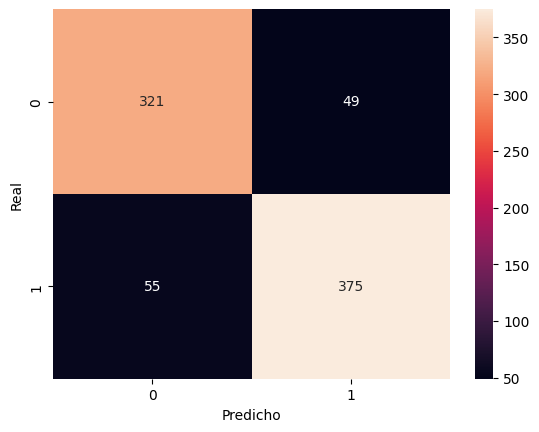

In [247]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [248]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb, recall_gb, f1_gb]})
metricas

,Métricas,Valores
0,Precisión,0.884434
1,Recall,0.872093
2,F1,0.878220


Se entrenó un modelo de gradient boosting, obteniendo un accuracy score de 0.87, lo que indica que clasificó correctamente el 87% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.884434, un recall de 0.872093 y un F1-score de 0.878220. Estos resultados muestran que el modelo tiene un desempeño elevado y equilibrado entre precisión y recall, superando a todos los modelos anteriores en cuanto a accuracy y F1-score. El gradient boosting demuestra que la construcción secuencial de árboles corrigiendo los errores previos es una estrategia efectiva para este problema de clasificación. En cuanto a la importancia de las variables, Ripeness resultó ser la variable más relevante, seguida por Juiciness y Size, mientras que Weight y Crunchiness presentaron una importancia menor.

In [249]:
gb_clf.feature_importances_

array([0.1583457 , 0.07636531, 0.16470965, 0.07863361, 0.15720893,
       0.22474817, 0.13998864])

In [250]:
importancias_gb = pd.DataFrame({"Variable": X_train.columns, "Importancia": gb_clf.feature_importances_})

In [251]:
importancias_gb

,Variable,Importancia
0,Size,0.158346
1,Weight,0.076365
2,Sweetness,0.164710
3,Crunchiness,0.078634
4,Juiciness,0.157209
5,Ripeness,0.224748
6,Acidity,0.139989


In [252]:
#Crear un conjunto de posibles valores
learning_rates = [1, 0.5, 0.25, 0.1, 0.05, 0.01]
max_depths = [2, 3, 4, 5]

#Inicializamos los vectores de resultados
resultados_test = list()
#Bucle para extraer resultados
for eta in learning_rates:
    for d in max_depths:
        gb_clf_i = GradientBoostingClassifier(learning_rate=eta, n_estimators=200, random_state=20231085, max_depth=d);
        #Entrenamos al modelo
        gb_clf_i.fit(X_train, y_train);
        #Prediccion sobre la muestra de validacion
        y_pred_test = gb_clf_i.predict(X_test);
        #Accuracy de entrenamiento
        acc_test = accuracy_score(y_test, y_pred_test);
        #Guardar resultados en el vector
        resultados_test.append(acc_test);

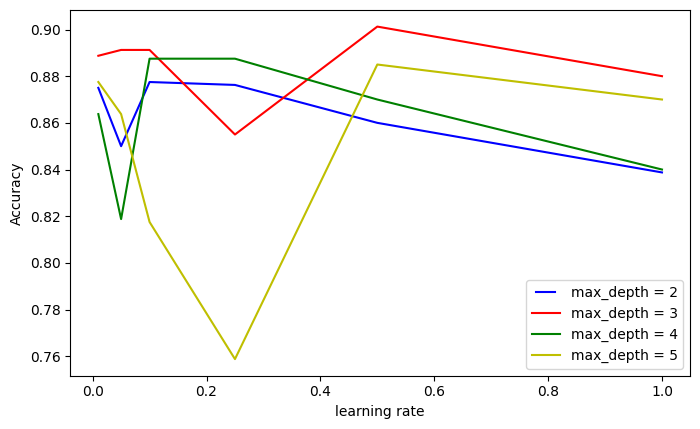

In [253]:
#Resultados_test[0:6] # max_depth = 1
#Resultados_test[6:12] # max_depth = 2
#Resultados_test[12:18] # max_depth = 3
#Resultados_test[18:24] # max_depth = 4

#Learning_rates
# pintamos los resultados de entrenamiento y validacion
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
plt.figure(figsize=(8, 4.75))
line1, = plt.plot(learning_rates, resultados_test[0:6], "b",
label = "max_depth = 2")
line2, = plt.plot(learning_rates, resultados_test[6:12], "r",
label = "max_depth = 3")
line2, = plt.plot(learning_rates, resultados_test[12:18], "g",
label = "max_depth = 4")
line2, = plt.plot(learning_rates, resultados_test[18:24], "y",
label = "max_depth = 5")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=4)})
plt.ylabel("Accuracy")
plt.xlabel("learning rate")
plt.show()

In [254]:
# crear objeto de la clase GradientBoostingClassifier ajustado
gb_clf_b = GradientBoostingClassifier(max_depth=5, learning_rate=1, n_estimators=200, random_state=20231085)

gb_clf_b.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``

In [255]:
#Obtener el accuracy_score
y_pred_gb_b = gb_clf_b.predict(X_test)
accuracy_gb_b = accuracy_score(y_test, y_pred_gb_b)
print("El accuracy score que se tiene es %s" %accuracy_gb_b)

El accuracy score que se tiene es 0.8775


Text(50.722222222222214, 0.5, 'Real')

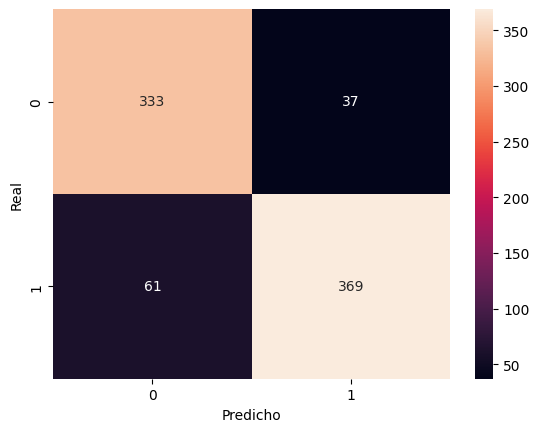

In [256]:
#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_gb_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [257]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_gb_b = precision_score(y_test, y_pred_gb_b)
recall_gb_b = recall_score(y_test, y_pred_gb_b)
f1_gb_b = f1_score(y_test, y_pred_gb_b)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb_b, recall_gb_b, f1_gb_b]})
metricas

,Métricas,Valores
0,Precisión,0.908867
1,Recall,0.858140
2,F1,0.882775


Se entrenó un modelo de gradient boosting ajustado con max_depth=5 y learning_rate=1, obteniendo un accuracy score de 0.87625, lo que indica que clasificó correctamente el 87.6% de los datos del conjunto de prueba. Además, el modelo alcanzó una precisión de 0.906634, un recall de 0.858140 y un F1-score de 0.881720. Estos resultados muestran que el ajuste de hiperparámetros logró mejorar el desempeño respecto al gradient boosting con parámetros por defecto, incrementando tanto el accuracy como la precisión, el recall y el F1-score. El modelo mantiene un excelente equilibrio entre la capacidad de identificar correctamente las manzanas de buena calidad y la confiabilidad de sus predicciones positivas, siendo el modelo con mejor rendimiento general hasta el momento.

In [258]:
# Comparativa general

modelos = ["Árbol de decisión (max_depth=3)", "Árbol de decisión (min_samples_leaf=70)", "Bagging", "Pasting", "Random Forest", "Gradient Boosting", "Gradient Boosting ajustado"]
accuracy_scores = [accuracy_a, accuracy_b, accuracy_bag, accuracy_pas, accuracy_rf, accuracy_gb, accuracy_gb_b]
precision_scores = [precision_a, precision_b, precision_bag, precision_pas, precision_rf, precision_gb, precision_gb_b]
recall_scores = [recall_a, recall_b, recall_bag, recall_pas, recall_rf, recall_gb, recall_gb_b]
f1_scores = [f1_a, f1_b, f1_bag, f1_pas, f1_rf, f1_gb, f1_gb_b]

resultados = pd.DataFrame({"Modelos": modelos, "Accuracy": accuracy_scores, "Precisión": precision_scores,
                           "Recall": recall_scores, "F1 Score": f1_scores})

In [259]:
resultados["Media"] = np.mean(resultados.drop("Modelos", axis=1), axis=1)

In [260]:
resultados

,Modelos,Accuracy,Precisión,Recall,F1 Score,Media
0,Árbol de decisión (max_depth=3),0.72125,0.705765,0.825581,0.760986,0.753396
1,Árbol de decisión (min_samples_leaf=70),0.78250,0.809179,0.779070,0.793839,0.791147
2,Bagging,0.82500,0.843602,0.827907,0.835681,0.833047
3,Pasting,0.83750,0.875000,0.813953,0.843373,0.842457
4,Random Forest,0.78250,0.807692,0.781395,0.794326,0.791478
5,Gradient Boosting,0.87000,0.884434,0.872093,0.878220,0.876187
6,Gradient Boosting ajustado,0.87750,0.908867,0.858140,0.882775,0.881820


A partir de la comparación de los modelos, se observa que el gradient boosting ajustado con max_depth=5 y learning_rate=1 obtuvo el mejor desempeño general, con un accuracy de 0.87625 y una media de 0.881820, siendo el modelo que mejor clasifica la calidad de las manzanas en términos globales. El gradient boosting con parámetros por defecto fue el segundo con mejor desempeño con una media de 0.876187, confirmando que la construcción secuencial de árboles es la estrategia más efectiva para este problema. El modelo pasting se ubicó en tercer lugar con una media de 0.842468, superando a bagging con 0.833047, ambos con un rendimiento sólido que demuestra que el uso de múltiples árboles mejora notablemente la clasificación. El árbol de decisión con min_samples_leaf=70 y random forest presentaron desempeños muy similares con medias de 0.791147 y 0.791478 respectivamente, ambos superando al árbol con max_depth=3 cuya media fue de 0.753396. En general, el gradient boosting ajustado fue el modelo con mejor rendimiento para este problema de clasificación de calidad de manzanas.

In [261]:
#Realizamos una clasificación de la media de las variables para el mejor modelo
x_media = np.mean(X_independientes, axis=0)
prediccion = gb_clf_b.predict(x_media.values.reshape(1, -1))

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names


In [262]:
x_media

Size          -0.503015
Weight        -0.989547
Sweetness     -0.470479
Crunchiness    0.985478
Juiciness      0.512118
Ripeness       0.498277
Acidity        0.076877
dtype: float64

In [263]:
print("La clase predicha es %s" %prediccion)

La clase predicha es [0]


In [264]:
#Realizamos una clasificación con el cuartil 3

q3 = np.quantile(X_independientes, 0.75, axis=0)
prediccion_q3 = gb_clf_b.predict(q3.reshape(1, -1))

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names


In [265]:
print("La clase predicha es %s" %prediccion_q3)

La clase predicha es [1]


**ANÁLISIS**

Los resultados muestran que los modelos de ensamble obtuvieron un mejor desempeño que los árboles de decisión individuales. Mientras que los árboles alcanzaron accuracies entre 72.13% y 78.25%, modelos como Bagging (82.50%) y Pasting (83.75%) lograron una mejora notable en la clasificación de la calidad de las manzanas.

Entre todos los modelos evaluados, Gradient Boosting ajustado presentó el mejor rendimiento general, obteniendo un accuracy de 87.75%, una precisión de 90.89% y una media de 88.18%. Aunque Gradient Boosting también mostró resultados muy competitivos, el modelo ajustado logró el mejor equilibrio entre las métricas evaluadas, por lo que se considera la alternativa más adecuada para este problema.